In [1]:
import brian2 as b2 # type: ignore
import matplotlib.pyplot as plt # type: ignore
%matplotlib inline

#### **Low-pass filter properties of a Hodgkin-Huxley neuron model**

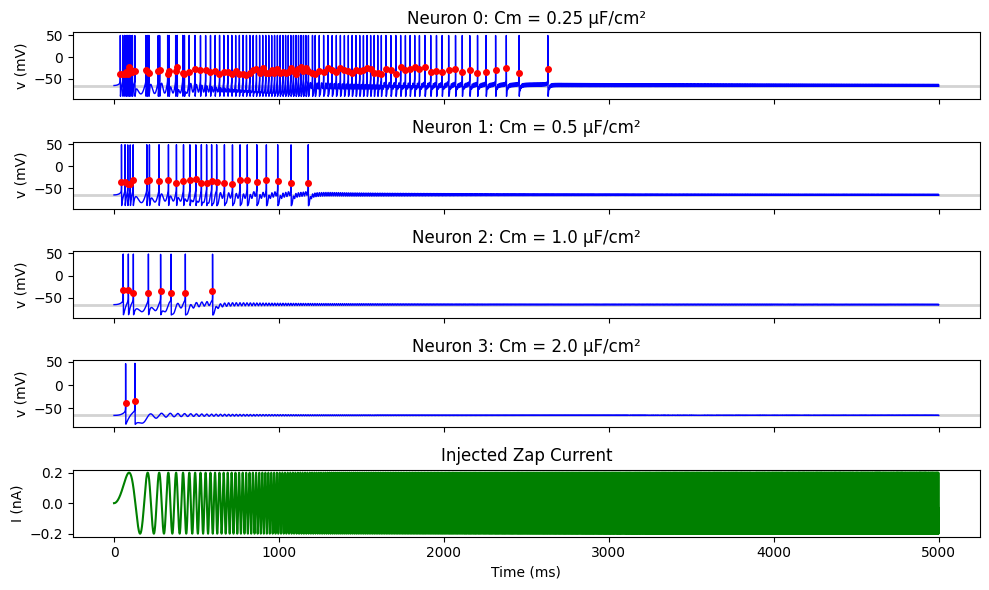

In [2]:
b2.start_scope()
b2.BrianLogger.suppress_name('unused_brian_object')

# Model parameters 
area = 20000 * b2.umetre**2
gl = 5e-5 * b2.siemens * b2.cm**-2 * area
El = -65 * b2.mV
EK = -90 * b2.mV
ENa = 50 * b2.mV
g_na = 100 * b2.msiemens * b2.cm**-2 * area
g_kd = 30 * b2.msiemens * b2.cm**-2 * area
VT = -63 * b2.mV

# Capacitance value
C_multipliers = b2.array([0.25, 0.5, 1.0, 2.0])
N_neurons = len(C_multipliers)

# Zap Current Parameters
A = 0.2 * b2.nA       
f_max = 300 * b2.Hz    
t_max = 5000 * b2.ms  

# Hodgkin-Huxley model
eqs_hh = '''
dv/dt = (gl*(El-v) - g_na*(m*m*m)*h*(v-ENa) - g_kd*(n*n*n*n)*(v-EK) + I)/C_var : volt
dm/dt = 0.32*(mV**-1)*(13.*mV-v+VT)/ \
        (exp((13.*mV-v+VT)/(4.*mV))-1.)/ms*(1-m)-0.28*(mV**-1)*(v-VT-40.*mV)/ \
        (exp((v-VT-40.*mV)/(5.*mV))-1.)/ms*m : 1
dn/dt = 0.032*(mV**-1)*(15.*mV-v+VT)/ \
        (exp((15.*mV-v+VT)/(5.*mV))-1.)/ms*(1.-n)-.5*exp((10.*mV-v+VT)/(40.*mV))/ms*n : 1
dh/dt = 0.128*exp((17.*mV-v+VT)/(18.*mV))/ms*(1.-h)-4./(1+exp((40.*mV-v+VT)/(5.*mV)))/ms*h : 1    
I = A * sin(pi*f_max*t**2/t_max) : amp 
C_var : farad '''

# Create a group of N_neurons
group = b2.NeuronGroup(N_neurons, eqs_hh, threshold='v > -40*mV', refractory='v > -40*mV', method='exponential_euler')
group.v = El
group.C_var  = C_multipliers * b2.ufarad * b2.cm**-2 * area

# Monitors 
state_mon = b2.StateMonitor(group, ['v', 'I'], record=True)
spike_mon = b2.SpikeMonitor(group, variables='v')

b2.run(t_max)

fig, axes = plt.subplots(N_neurons + 1, 1, figsize=(10, 1.2 * (N_neurons + 1)), sharex=True)
for i in range(N_neurons):
    ax = axes[i]
    ax.axhline(El / b2.mV, ls='-', c='lightgray', lw=2)
    ax.plot(state_mon.t / b2.ms, state_mon.v[i] / b2.mV, '-b', lw=1)
    
    spike_times = spike_mon.t[spike_mon.i == i]
    spike_v = spike_mon.v[spike_mon.i == i]
    ax.plot(spike_times / b2.ms, spike_v / b2.mV, 'or', markersize=4)
    
    ax.set_ylabel('v (mV)')
    ax.set_title(f'Neuron {i}: Cm = {C_multipliers[i]} µF/cm²')

ax_I = axes[-1]
ax_I.plot(state_mon.t / b2.ms, state_mon.I[0] / b2.nA, '-g')
ax_I.set_xlabel('Time (ms)')
ax_I.set_ylabel('I (nA)')
ax_I.set_title('Injected Zap Current')

plt.tight_layout()
plt.show()

#### **Band-pass filter due to slow restorative current**

In [33]:
b2.start_scope()
b2.BrianLogger.suppress_name('unused_brian_object')

# Model parameters 
area = 20000 * b2.umetre**2
Cm = 1 * b2.ufarad * b2.cm**-2 * area
gl = 5e-5 * b2.siemens * b2.cm**-2 * area
El = -65 * b2.mV
EK = -90 * b2.mV
ENa = 50 * b2.mV
g_na = 100 * b2.msiemens * b2.cm**-2 * area
g_kd = 30 * b2.msiemens * b2.cm**-2 * area
VT = -63 * b2.mV

# M-current parameters 
g_M = 5 * b2.msiemens * b2.cm**-2 * area  
tau_z = 50 * b2.ms  

test_frequencies = b2.arange(1, 75, 1) * b2.Hz
N_neurons = len(test_frequencies)
A = 0.55 * b2.nA        
t_max = 2000 * b2.ms  

# Hodgkin-Huxley + M-current 
eqs_resonant = '''
dv/dt = (gl*(El-v) - g_na*(m*m*m)*h*(v-ENa) - g_kd*(n*n*n*n)*(v-EK) - g_M*z*(v-EK) + I_inj)/Cm : volt
dm/dt = 0.32*(mV**-1)*(13.*mV-v+VT)/ \
        (exp((13.*mV-v+VT)/(4.*mV))-1.)/ms*(1-m)-0.28*(mV**-1)*(v-VT-40.*mV)/ \
        (exp((v-VT-40.*mV)/(5.*mV))-1.)/ms*m : 1
dn/dt = 0.032*(mV**-1)*(15.*mV-v+VT)/ \
        (exp((15.*mV-v+VT)/(5.*mV))-1.)/ms*(1.-n)-.5*exp((10.*mV-v+VT)/(40.*mV))/ms*n : 1
dh/dt = 0.128*exp((17.*mV-v+VT)/(18.*mV))/ms*(1.-h)-4./(1+exp((40.*mV-v+VT)/(5.*mV)))/ms*h : 1

dz/dt = (z_inf - z) / tau_z : 1
z_inf = 1 / (1 + exp(-(v + 35*mV)/(5*mV))) : 1

I_inj = A * sin(2 * pi * f_in * t) : amp
f_in : Hz '''

group = b2.NeuronGroup(N_neurons, eqs_resonant, threshold = 'v > -40*mV', refractory = 'v > -40*mV', method = 'exponential_euler')
group.v = El
group.z = 0  
group.f_in = test_frequencies

# Record specific frequencies
target_freqs_hz = [1, 16, 25, 35, 45]
indices_to_record = [b2.where(test_frequencies == f * b2.Hz)[0][0] for f in target_freqs_hz]

spike_mon = b2.SpikeMonitor(group)
state_mon = b2.StateMonitor(group, 'v', record = indices_to_record)
b2.run(t_max)

# Metrics
spike_counts = spike_mon.count
firing_rates = spike_counts / t_max

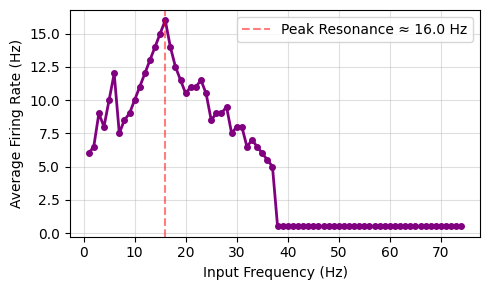

In [39]:
fig1, ax1 = plt.subplots(figsize = (5, 3))
freqs_hz = test_frequencies / b2.Hz
rates_hz = firing_rates / b2.Hz

ax1.plot(freqs_hz, rates_hz, '-o', c = 'purple', markersize = 4, linewidth = 2)
ax1.set_xlabel('Input Frequency (Hz)')
ax1.set_ylabel('Average Firing Rate (Hz)')
ax1.grid(True, alpha = 0.4)

max_rate_idx = b2.argmax(rates_hz)
resonant_freq = freqs_hz[max_rate_idx]
ax1.axvline(resonant_freq, color = 'red', linestyle = '--', alpha = 0.5, label = f'Peak Resonance ≈ {resonant_freq} Hz')
ax1.legend()
plt.tight_layout()

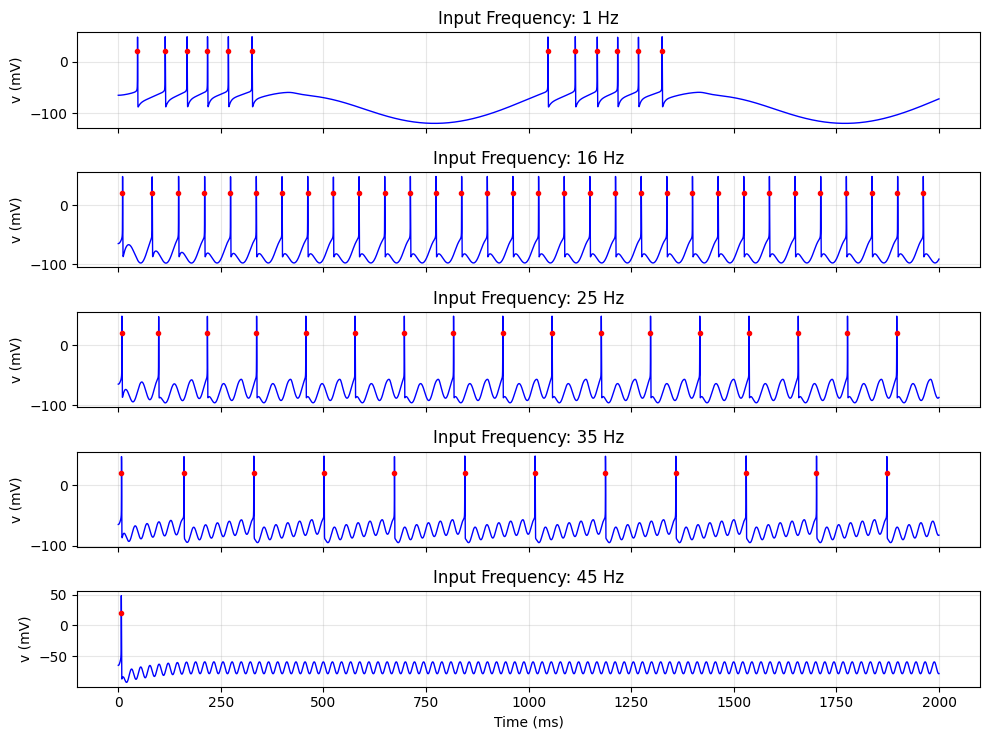

In [ ]:
fig2, axes = plt.subplots(len(target_freqs_hz), 1, figsize = (10, 1.5 * len(target_freqs_hz)), sharex=True)

for i, (ax, freq, idx) in enumerate(zip(axes, target_freqs_hz, indices_to_record)):
    voltage_trace = state_mon.v[i] / b2.mV
    time_trace = state_mon.t / b2.ms
    ax.plot(time_trace, voltage_trace, '-b', lw=1)
    
    spike_times = spike_mon.t[spike_mon.i == idx] / b2.ms
    ax.plot(spike_times, b2.ones_like(spike_times) * 20, 'or', markersize=3) 
    
    ax.set_ylabel('v (mV)')
    ax.set_title(f'Input Frequency: {freq} Hz')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (ms)')
plt.tight_layout()
plt.show()

#### **Subthreshold resonance**

In [72]:
import numpy as np
b2.start_scope()
b2.BrianLogger.suppress_name('unused_brian_object')

# Model parameters 
area = 20000 * b2.umetre**2
Cm = 1 * b2.ufarad * b2.cm**-2 * area
gl = 5e-5 * b2.siemens * b2.cm**-2 * area
El = -65 * b2.mV
EK = -90 * b2.mV
ENa = 50 * b2.mV
g_na = 100 * b2.msiemens * b2.cm**-2 * area
g_kd = 30 * b2.msiemens * b2.cm**-2 * area
VT = -63 * b2.mV

# M-current parameters 
g_M = 8 * b2.msiemens * b2.cm**-2 * area  
tau_z = 15 * b2.ms  

test_frequencies = b2.arange(1, 75, 1) * b2.Hz
N_neurons = len(test_frequencies)
A = 0.03 * b2.nA        
t_max = 5000 * b2.ms  

# Hodgkin-Huxley + M-current 
eqs_resonant = '''
dv/dt = (gl*(El-v) - g_na*(m*m*m)*h*(v-ENa) - g_kd*(n*n*n*n)*(v-EK) - g_M*z*(v-EK) + I_inj)/Cm : volt
dm/dt = 0.32*(mV**-1)*(13.*mV-v+VT)/ \
        (exp((13.*mV-v+VT)/(4.*mV))-1.)/ms*(1-m)-0.28*(mV**-1)*(v-VT-40.*mV)/ \
        (exp((v-VT-40.*mV)/(5.*mV))-1.)/ms*m : 1
dn/dt = 0.032*(mV**-1)*(15.*mV-v+VT)/ \
        (exp((15.*mV-v+VT)/(5.*mV))-1.)/ms*(1.-n)-.5*exp((10.*mV-v+VT)/(40.*mV))/ms*n : 1
dh/dt = 0.128*exp((17.*mV-v+VT)/(18.*mV))/ms*(1.-h)-4./(1+exp((40.*mV-v+VT)/(5.*mV)))/ms*h : 1

dz/dt = (z_inf - z) / tau_z : 1
z_inf = 1 / (1 + exp(-(v + 35*mV)/(5*mV))) : 1

I_inj = A * sin(2 * pi * f_in * t) : amp
f_in : Hz '''

group = b2.NeuronGroup(N_neurons, eqs_resonant, threshold = 'v > -40*mV', refractory = 'v > -40*mV', method = 'exponential_euler')
group.v = El
group.z = 0  
group.f_in = test_frequencies

# We need every trace to calculate the amplitude for each frequency
state_mon = b2.StateMonitor(group, 'v', record = True)
b2.run(t_max)

Calculating the impedance profile:

In [73]:
# Discard the first 1000 ms to let the active currents settle into a steady state
steady_state_time = 1000 * b2.ms
steady_state_idx = int(steady_state_time / b2.defaultclock.dt)
# Slice the voltage array [all neurons, steady_state_time_onwards]
v_steady = state_mon.v[:, steady_state_idx:] / b2.mV

# Peak to peak amplitude
p2p_amp = (np.max(v_steady, axis=1) - np.min(v_steady, axis=1)) / 2.0
impedance = p2p_amp / (A / b2.nA)

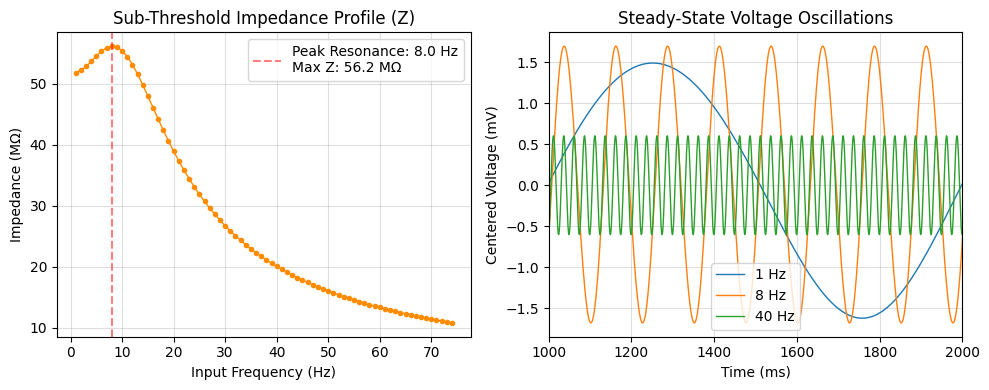

In [74]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 4))

freqs_hz = test_frequencies / b2.Hz
ax1.plot(freqs_hz, impedance, '-o', c = 'darkorange', markersize = 3, linewidth = 1)
ax1.set_xlabel('Input Frequency (Hz)')
ax1.set_ylabel('Impedance (MΩ)')
ax1.set_title('Sub-Threshold Impedance Profile (Z)')
ax1.grid(True, alpha = 0.4)

max_z_idx = b2.argmax(impedance)
resonant_freq = freqs_hz[max_z_idx]
max_z = impedance[max_z_idx]
ax1.axvline(resonant_freq, color = 'red', linestyle = '--', alpha = 0.5, 
            label = f'Peak Resonance: {resonant_freq} Hz\nMax Z: {max_z:.1f} MΩ')
ax1.legend()

target_plot_freqs = [1, int(resonant_freq), 40]
time_trace = state_mon.t[steady_state_idx:] / b2.ms
for freq in target_plot_freqs:
    idx = b2.where(freqs_hz == freq)[0][0]
    v_centered = v_steady[idx] - b2.mean(v_steady[idx])
    ax2.plot(time_trace, v_centered, lw = 1, label = f'{freq} Hz')

ax2.set_xlim(1000, 2000) 
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Centered Voltage (mV)')
ax2.set_title('Steady-State Voltage Oscillations')
ax2.legend()
ax2.grid(True, alpha = 0.4)

plt.tight_layout()
plt.show()

#### **Resonant neuron injected with a zap current**

In [77]:
import brian2 as b2
import matplotlib.pyplot as plt
b2.start_scope()
b2.BrianLogger.suppress_name('unused_brian_object')

# Model parameters
area = 20000 * b2.umetre**2
Cm = 1 * b2.ufarad * b2.cm**-2 * area
gl = 5e-5 * b2.siemens * b2.cm**-2 * area
El = -65 * b2.mV
EK = -90 * b2.mV
ENa = 50 * b2.mV
g_na = 100 * b2.msiemens * b2.cm**-2 * area
g_kd = 30 * b2.msiemens * b2.cm**-2 * area
VT = -63 * b2.mV

# M-current 
g_M = 8 * b2.msiemens * b2.cm**-2 * area  
tau_z = 15 * b2.ms  

# Zap current (input)
A = 0.03 * b2.nA        
f0 = 1 * b2.Hz          # Starting frequency
f1 = 70 * b2.Hz         # Ending frequency
t_max = 10000 * b2.ms   # 10 seconds duration

# Hodgkin-Huxley + M-current
eqs_resonant = '''
dv/dt = (gl*(El-v) - g_na*(m*m*m)*h*(v-ENa) - g_kd*(n*n*n*n)*(v-EK) - g_M*z*(v-EK) + I_inj)/Cm : volt
dm/dt = 0.32*(mV**-1)*(13.*mV-v+VT)/ \
        (exp((13.*mV-v+VT)/(4.*mV))-1.)/ms*(1-m)-0.28*(mV**-1)*(v-VT-40.*mV)/ \
        (exp((v-VT-40.*mV)/(5.*mV))-1.)/ms*m : 1
dn/dt = 0.032*(mV**-1)*(15.*mV-v+VT)/ \
        (exp((15.*mV-v+VT)/(5.*mV))-1.)/ms*(1.-n)-.5*exp((10.*mV-v+VT)/(40.*mV))/ms*n : 1
dh/dt = 0.128*exp((17.*mV-v+VT)/(18.*mV))/ms*(1.-h)-4./(1+exp((40.*mV-v+VT)/(5.*mV)))/ms*h : 1

dz/dt = (z_inf - z) / tau_z : 1
z_inf = 1 / (1 + exp(-(v + 35*mV)/(5*mV))) : 1
# Continuous zap phase equation
I_inj = A * sin(2 * pi * (f0 * t + (f1 - f0) / (2 * t_max) * t**2)) : amp '''

group = b2.NeuronGroup(1, eqs_resonant, threshold = 'v > -40*mV', refractory = 'v > -40*mV', method = 'exponential_euler')
group.v = -69 * b2.mV
group.z = 0  

state_mon = b2.StateMonitor(group, ['v', 'I_inj'], record = True)
b2.run(t_max)

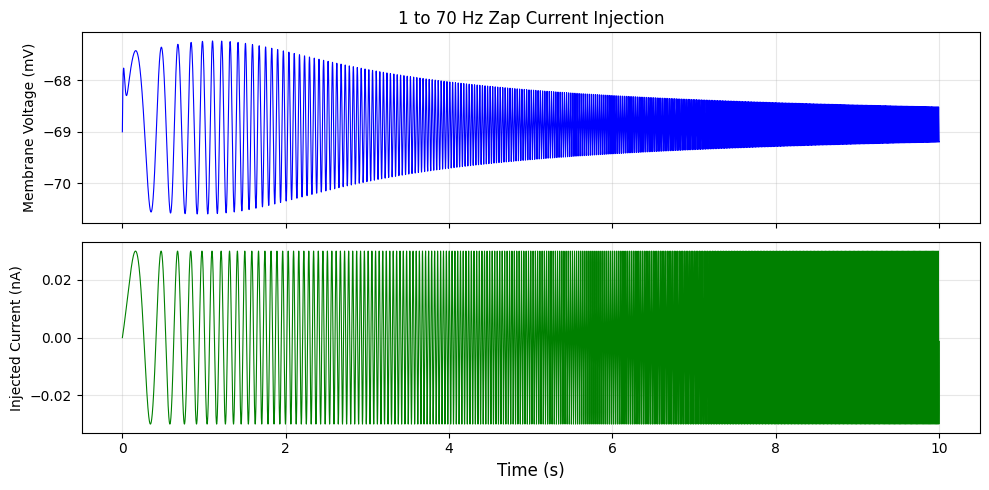

In [83]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (10, 5), sharex = True)
time_sec = state_mon.t / b2.second

voltage = state_mon.v[0] / b2.mV
ax1.plot(time_sec, voltage, '-b', lw = 0.8)
ax1.set_ylabel('Membrane Voltage (mV)')
ax1.set_title('1 to 70 Hz Zap Current Injection', fontsize = 12)
ax1.grid(True, alpha = 0.3)

current = state_mon.I_inj[0] / b2.nA
ax2.plot(time_sec, current, '-g', lw = 0.8)
ax2.set_xlabel('Time (s)', fontsize = 12)
ax2.set_ylabel('Injected Current (nA)')
ax2.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()